![Alt Text](https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/header.png)

<a href="https://colab.research.google.com/github/msfasha/307304-Data-Mining/blob/main/Part%202-Regression/2-2-multiple%20linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction To Multiple Linear Regression

### Topics and Outcomes
- Introduce Multiple Regression.

### What is multiple Linear Regression?
Multiple Linear Regression is an **extension** of simple linear regression that allows for predicting a dependent variable based on multiple independent variables. The general form of the model is expressed as:

$$
y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n
$$

Where:
- $ y \in Y $ is the dependent variable (the value we aim to predict).
- $ \beta_0 $ is the intercept (constant term).
- $ \beta_1, \beta_2, \dots, \beta_n $ are the coefficients for the independent variables.
- $ X_1, X_2, \dots, X_n $ are the independent variables (features that influence $ y $).

The model gets the best regression fit line by finding the best values for $ \beta_0 $, $ \beta_1 $ and so on.

### Steps of Multiple Linear Regression Model
1. **Data Pre Processing**
- Importing the Libraries.
- Importing the Data Set.
- Splitting the Data set into Training Set and Test Set.
2. **Define the Model**:
   - The model is defined as a linear combination of the independent variables. The coefficients ($\beta_1 $, $\beta_2$, $...$, $\beta_n$) represent how much each independent variable contributes to predicting ( y ).
3. **Fit the Model**:
   - Using a method such as **Ordinary Least Squares (OLS)**, estimate the coefficients by minimizing the sum of the squared differences between the actual values of $y$ and the predicted values $\hat{y}$.

4. **Make Predictions**:
   - Once the model is trained, use the estimated coefficients to make predictions for new data points.

5. **Evaluate the Model**:
   - After fitting the model, evaluate its performance using metrics such as **R-squared** (which tells how well the model explains the variance in the data) and **Mean Squared Error (MSE)** to measure prediction accuracy.

## **Practical Example**
## **Predicting Apartment Price based on Appartment Features**

In this example, we’ll predict **price** of an apartment based on its area size, number of rooms, age of the building, floor number.<br>

#### **Step 1: Import Libraries**

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

#### **Step 2: Open Dataset**
We will use the house/apartment prices dataset to demonstrate multiple linear regression

In [19]:
df = pd.read_csv("https://raw.githubusercontent.com/msfasha/307304-Data-Mining/refs/heads/main/datasets/apartment_prices.csv")
df

,Square_Area,Num_Rooms,Age_of_Building,Floor_Level,City,Price
0,162,1,15,12,Amman,74900.0
1,152,5,8,8,Aqaba,79720.0
2,74,3,2,8,Irbid,43200.0
3,166,1,3,18,Irbid,69800.0
4,131,3,14,15,Aqaba,63160.0
...,...,...,...,...,...,...
495,177,1,6,12,Irbid,64100.0
496,79,5,9,13,Irbid,52700.0
497,106,3,7,14,Aqaba,60160.0
498,108,3,9,18,Amman,72600.0


#### **Step 3: Define Features and Target**
We use **Square_Area**, **Num_Rooms**, **Age_of_Building** and **Floor_Level** as features and **Price** as the target.

In [21]:
# Features and Target
X = df[['Square_Area', 'Num_Rooms', 'Age_of_Building','Floor_Level']]  # Independent variables
y = df['Price']  # Dependent variable (Sales)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Step 4: Train the Model**


In [22]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Coefficients and Intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 364.36926791 5064.2938487  -925.54218137  951.56065025]
Intercept: 461.27020385613287


#### **Step 5: Make Predictions**

In [23]:
# Predict the target variable for the test set
y_pred = model.predict(X_test)

# Display the predictions alongside the actual values
df = pd.DataFrame({'Actual': np.round(y_test,2), 'Predicted': np.round(y_pred,2),'Residual': np.round(np.abs(y_test - y_pred),2)})
df

,Actual,Predicted,Residual
361,102550.0,89530.89,13019.11
73,54200.0,62947.21,8747.21
374,44000.0,44989.04,989.04
155,67000.0,77635.12,10635.12
104,63700.0,57098.21,6601.79
...,...,...,...
347,73360.0,75233.49,1873.49
86,36800.0,32110.44,4689.56
75,85500.0,75366.09,10133.91
438,89200.0,74516.43,14683.57


#### **Step 6: Evaluate the Model**
We evaluate the model using **MSE**, **MAE**, and **R-squared**.

In [24]:
# R-squared (R²)
r2 = r2_score(y_test, y_pred)
print("R-squared (R²):", round(r2,2))

R-squared (R²): 0.84


#### **Step 7: Plotting the Performance**

We visualize the predicted vs actual sales values to assess model performance.

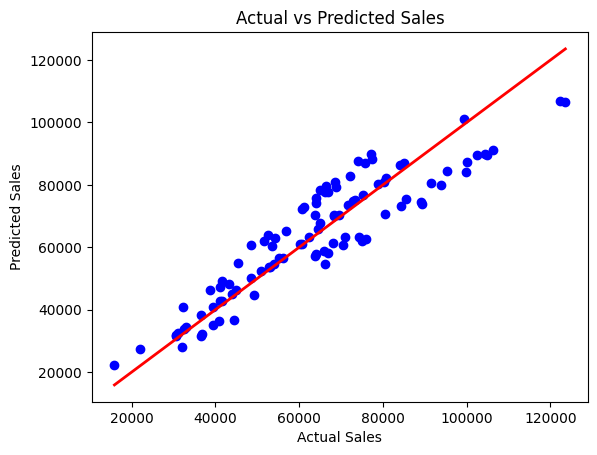

In [33]:
# Plot actual vs predicted values
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)  # Line of perfect fit
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

### Comments on the Performance Plot
This plot is a scatter plot of **actual sales** values versus **predicted sales** values, with a red line representing the line of perfect fit (where actual equals predicted). Here are some thoughts based on the shape and distribution of the points:

1. **General Alignment with Perfect Fit**:
   - The data points generally align along the red line, indicating that the model is making reasonably accurate predictions.
   - Points closely clustered around the line suggest good model performance.

2. **Variance and Spread**:
   - <span style="color: red;">The spread of points widens slightly as sales values increase, indicating that the model may be slightly less accurate for higher sales values. This pattern can be common in regression models if there’s more variability in the data at higher ranges, potentially due to heteroscedasticity (non-constant variance of residuals).</span>

3. **Linear Model Appropriateness**:
   - If this plot generally follows a linear pattern (as it does here), it suggests that a linear regression model is appropriate. If you noticed a nonlinear pattern, it might suggest trying a nonlinear regression approach.

### Suggestions

- **Investigate Outliers**: Look into the data points that are far from the line to understand why the model struggled with those predictions.
- **Check for Heteroscedasticity**: You could perform a residual plot (residuals vs. predicted values) to check if there’s increasing variance, which may indicate heteroscedasticity.
- **Consider Model Complexity**: If the model consistently struggles at higher values, a more complex model (e.g., polynomial regression) or transformations on the target variable might improve performance.

Overall, this plot suggests that the model is performing reasonably well, but further analysis (especially of residuals) could help refine it.

From the residual plot, it appears that there is a **fanning-out pattern** in the residuals, where the variance of the residuals increases as the predicted values increase. This pattern is indicative of **heteroscedasticity**.

### Interpretation of the Plot

1. **Fanning-Out Pattern**:
   - The residuals are not evenly distributed around the red horizontal line (at zero) with a constant spread.
   - Instead, the spread of residuals grows wider as the predicted values increase, suggesting that the variance of errors is not constant.

2. **Implications**:
   - Heteroscedasticity means that the model's errors vary at different levels of the predicted values, which violates one of the core assumptions of linear regression.
   - This can lead to inefficient estimates of the coefficients and may make the model less reliable, especially in predictions for larger values.

---

## Discussion of Results

The accuracy, as represented by the \(R^2\) score of **0.87**, suggests that the model is capturing about 87% of the variance in the data, which is lower than desired for many business applications.

Here are a few potential steps you can take to improve the model’s accuracy:

### 1. **Check Feature Importance**
   - The current model may not be capturing all the important relationships in the data. Try using **feature importance** techniques (like looking at the coefficients of the linear model) to determine if any of the variables have a disproportionately low or high impact.
   - You could try adding more relevant features if available or removing features that don't seem to contribute significantly.

### 2. **Polynomial Features**
   - Linear regression assumes a linear relationship between the features and the target. However, if the true relationship is nonlinear, linear regression might not be a good fit.
   - Try adding **polynomial features** (interaction terms) using `PolynomialFeatures` from `scikit-learn`.

   ```python
   from sklearn.preprocessing import PolynomialFeatures

   poly = PolynomialFeatures(degree=2, include_bias=False)
   X_poly = poly.fit_transform(X)
   
   X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
   
   model = LinearRegression()
   model.fit(X_train_poly, y_train)
   
   y_pred = model.predict(X_test_poly)
   ```

### 3. **Regularization**
   - Try using **regularization techniques** like **Ridge Regression** or **Lasso Regression** to penalize large coefficients and reduce overfitting.
   
   ```python
   from sklearn.linear_model import Ridge

   model = Ridge(alpha=1.0)
   model.fit(X_train, y_train)
   ```

### 4. **Cross-Validation**
   - Use **cross-validation** to ensure your model isn't overfitting on the training set.
   
   ```python
   from sklearn.model_selection import cross_val_score

   scores = cross_val_score(model, X, y, cv=5, scoring='r2')
   print("Average R^2 from cross-validation:", np.mean(scores))
   ```

### 5. **Scale the Data**
   - Scaling the numerical features can often improve the performance of linear models, especially if the features have different magnitudes.
   
   ```python
   from sklearn.preprocessing import StandardScaler

   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)
   ```

### 6. **Outlier Detection**
   - Outliers in the dataset could be adversely affecting the performance of the model. Check if any observations have extreme values that might be skewing the results.

### 7. **Interaction Terms**
   - Consider adding interaction terms between variables. For example, TV and Radio spend might have an interaction effect that influences sales.

### 8. **Add More Data**
   - If possible, adding more data (e.g., more records, more features) can help improve the accuracy by giving the model more examples to learn from.

## Complete Model Code

In [35]:
df = pd.read_csv("https://raw.githubusercontent.com/msfasha/307304-Data-Mining/refs/heads/main/datasets/apartment_prices.csv")

# Features and Target
X = df[['Square_Area', 'Num_Rooms', 'Age_of_Building','Floor_Level']]  # Independent variables
y = df['Price']  # Dependent variable (Sales)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Coefficients and Intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 364.36926791 5064.2938487  -925.54218137  951.56065025]
Intercept: 461.27020385613287
